In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


Class Name                | Image Count
----------------------------------------
Bored                     | 1019      
Confused                  | 3315      
Deviated                  | 3030      
Focused                   | 891       
Sleepy                    | 2481      
----------------------------------------
TOTAL DATASET SIZE        | 10736     



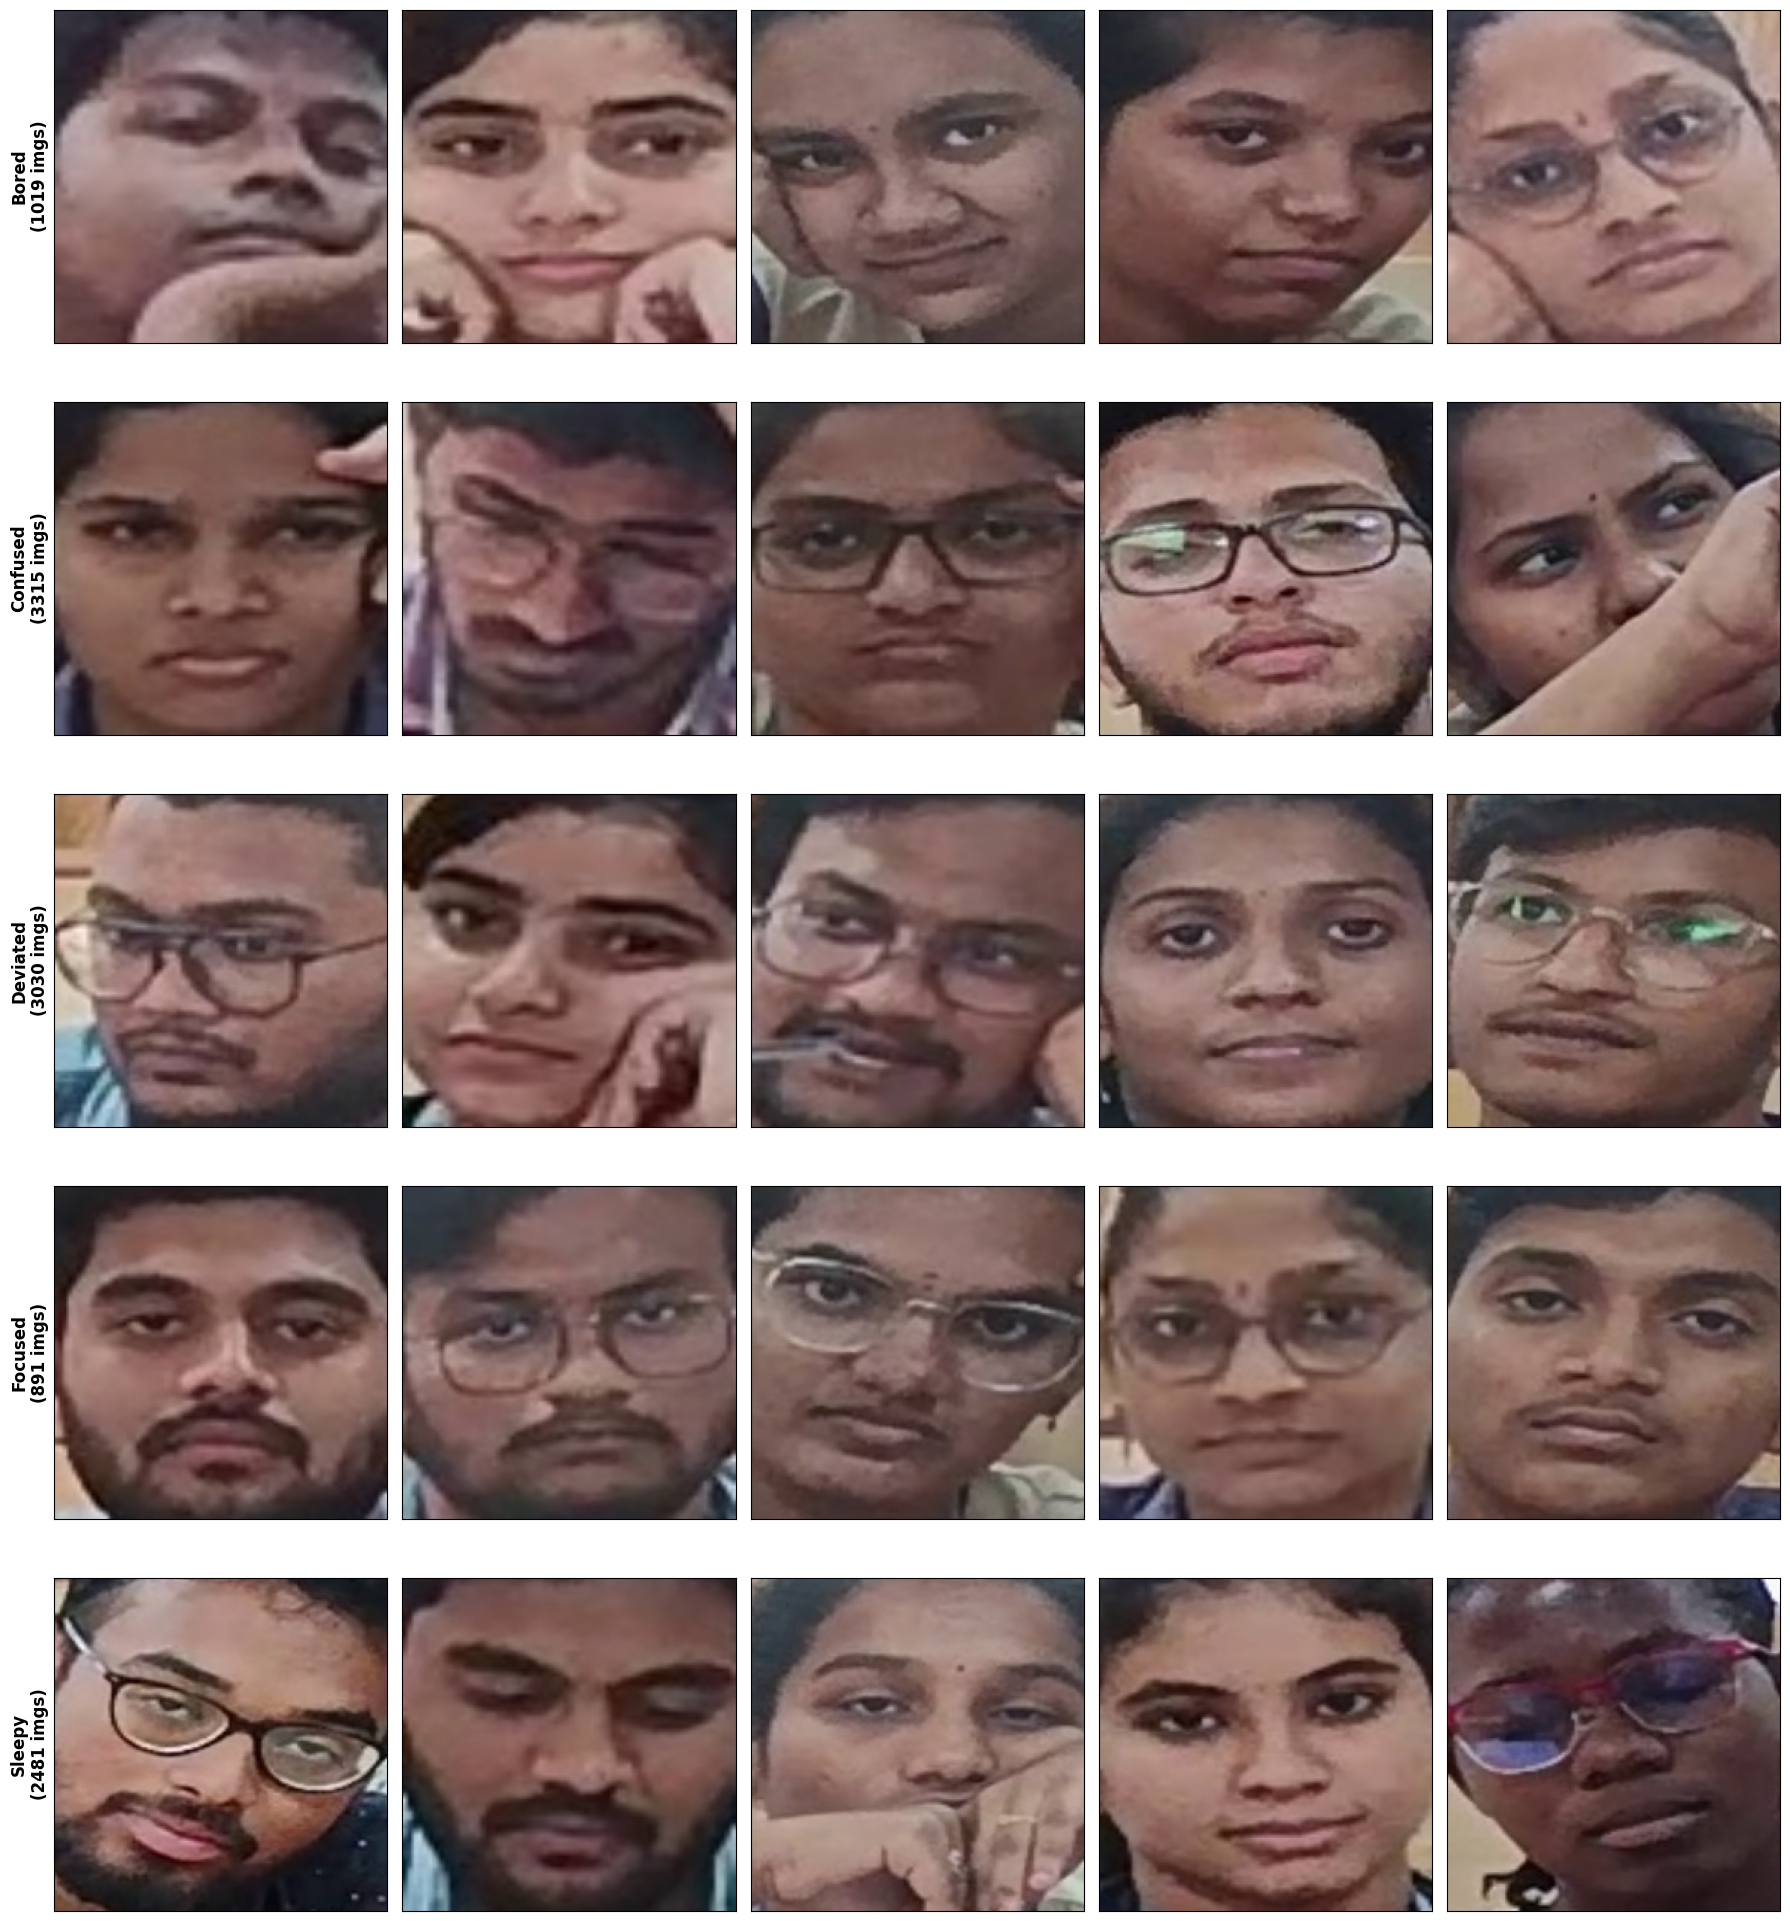

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

dataset_path = '/content/drive/MyDrive/cropped_dataset'


classes = sorted([d for d in os.listdir(dataset_path)
                  if os.path.isdir(os.path.join(dataset_path, d))
                  and not d.startswith('.')])


print(f"{'Class Name':<25} | {'Image Count':<10}")
print("-" * 40)

total_images = 0
class_data = []

for cls in classes:
    cls_full_path = os.path.join(dataset_path, cls)

    
    all_images = [f for f in os.listdir(cls_full_path)
                  if os.path.isfile(os.path.join(cls_full_path, f))
                  and not f.startswith('.')]

    count = len(all_images)
    total_images += count
    print(f"{cls:<25} | {count:<10}")

    
    class_data.append({'name': cls, 'images': all_images, 'path': cls_full_path, 'count': count})

print("-" * 40)
print(f"{'TOTAL DATASET SIZE':<25} | {total_images:<10}\n")



imgs_per_row = 5
num_classes = len(classes)


plt.figure(figsize=(18, 4 * num_classes))

for row_idx, data in enumerate(class_data):
    cls_name = data['name']
    all_images = data['images']
    cls_path = data['path']

    
    sample_size = min(len(all_images), imgs_per_row)
    selected_images = random.sample(all_images, sample_size)

    for col_idx, img_name in enumerate(selected_images):
        img_path = os.path.join(cls_path, img_name)

        
        plt.subplot(num_classes, imgs_per_row, (row_idx * imgs_per_row) + col_idx + 1)

        try:
            img = mpimg.imread(img_path)
            plt.imshow(img)

            
            if col_idx == 0:
                plt.ylabel(f"{cls_name}\n({data['count']} imgs)", fontsize=12, fontweight='bold')
        except Exception as e:
            plt.text(0.5, 0.5, 'Error', ha='center')

        plt.xticks([])
        plt.yticks([])

plt.tight_layout()
plt.show()

In [ ]:
import os

dataset_path = '/content/drive/MyDrive/cropped_dataset'


classes = [d for d in os.listdir(dataset_path)
           if os.path.isdir(os.path.join(dataset_path, d)) and not d.startswith('.')]

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)

    
    images = [f for f in os.listdir(cls_path)
              if os.path.isfile(os.path.join(cls_path, f)) and not f.startswith('.')]

    
    images.sort()

    print(f"Renaming {len(images)} images in class: {cls}...")

    
    temp_names = []
    for i, filename in enumerate(images):
        ext = os.path.splitext(filename)[1]
        old_path = os.path.join(cls_path, filename)
        temp_path = os.path.join(cls_path, f"temp_rename_{i}{ext}")
        os.rename(old_path, temp_path)
        temp_names.append(f"temp_rename_{i}{ext}")

    
    for i, temp_name in enumerate(temp_names, start=1):
        ext = os.path.splitext(temp_name)[1]
        old_temp_path = os.path.join(cls_path, temp_name)
        final_path = os.path.join(cls_path, f"{i}{ext}")
        os.rename(old_temp_path, final_path)

print("\nSuccess! All images have been renamed to sequential IDs.")

Renaming 891 images in class: Focused...
Renaming 2481 images in class: Sleepy...
Renaming 3030 images in class: Deviated...
Renaming 3315 images in class: Confused...
Renaming 1019 images in class: Bored...

Success! All images have been renamed to sequential IDs.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt


dataset_path = '/content/drive/MyDrive/cropped_dataset'
IMG_SIZE = (224, 224)  
BATCH_SIZE = 32


print("Creating Training Dataset...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

print("\nCreating Validation Dataset...")
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)


data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


def preprocess(image, label):
   
    image = layers.Rescaling(1./255)(image)
    return image, label


AUTOTUNE = tf.data.AUTOTUNE


train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)


val_ds = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("\nPreprocessing and complete. Data is ready for training.")

Creating Training Dataset...
Found 10736 files belonging to 5 classes.
Using 8589 files for training.

Creating Validation Dataset...
Found 10736 files belonging to 5 classes.
Using 2147 files for validation.

Preprocessing complete. Data is ready for training.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models


IMG_SHAPE = (224, 224, 3)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,  
    weights='imagenet'
)


base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),  
    layers.Dense(len(classes), activation='softmax') 
])


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)